In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('https://raw.githubusercontent.com/AsaelP25/datamining/refs/heads/main/archivos/Prestige_modificado.csv', sep=';')
display(df.head())

,occupation,education,income,women,prestige,census,type_num
0,gov.administrators,13.11,12351,11.16,68.8,1113,1
1,general.managers,12.26,25879,4.02,69.1,1130,1
2,accountants,12.77,9271,15.70,63.4,1171,1
3,purchasing.officers,11.42,8865,9.11,56.8,1175,1
4,chemists,14.62,8403,11.68,73.5,2111,1


Validación de dimensiones

---



In [8]:
df.shape

(102, 7)

Revisión de tipos de datos

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB


Revisión de valores nulos

In [10]:
df.isnull().sum()

,0
occupation,0
education,0
income,0
women,0
prestige,0
census,0
type_num,0


Revisión de registros duplicados

In [11]:
df.duplicated().sum()

np.int64(0)

Estadística descriptiva

In [12]:
df.describe()

,education,income,women,prestige,census,type_num
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,10.738039,6797.901961,28.979020,46.833333,5401.774510,1.843137
std,2.728444,4245.922227,31.724931,17.204486,2644.993215,0.817447
min,6.380000,611.000000,0.000000,14.800000,1113.000000,0.000000
25%,8.445000,4106.000000,3.592500,35.225000,3120.500000,1.000000
50%,10.540000,5930.500000,13.600000,43.600000,5135.000000,2.000000
75%,12.647500,8187.250000,52.202500,59.275000,8312.500000,2.000000
max,15.970000,25879.000000,97.510000,87.200000,9517.000000,3.000000


Analisis de relación entre variables

In [13]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
matriz_correlacion = variables_numericas.corr()

print(matriz_correlacion.round(3))
print("-" * 80)
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))


           education  income  women  prestige  census  type_num
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000
--------------------------------------------------------------------------------
prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


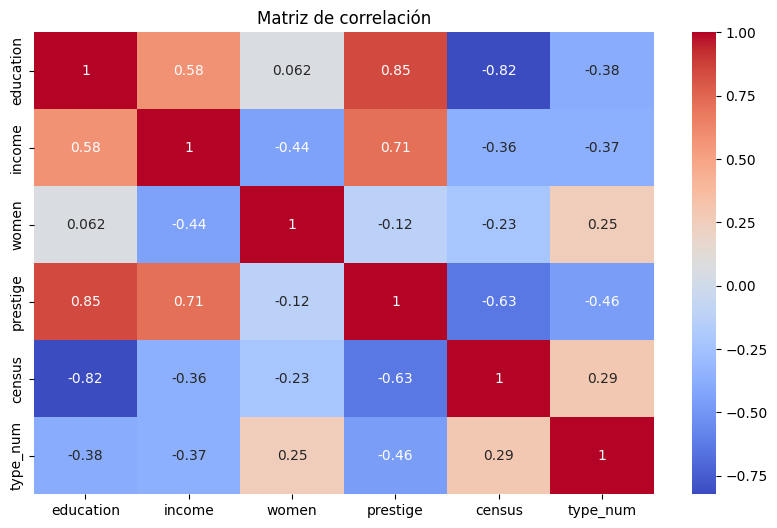

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

Visualización de resultados

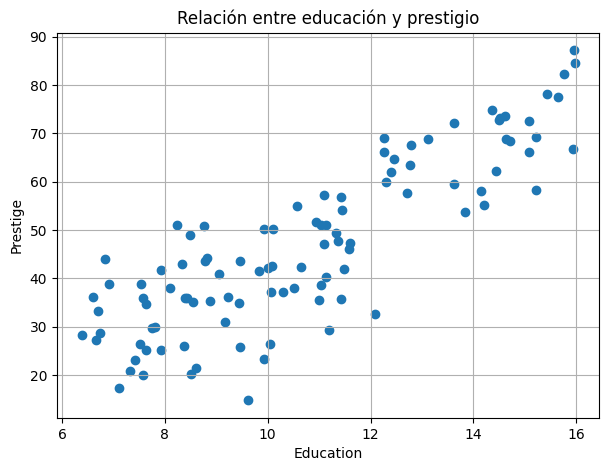

In [16]:
plt.figure(figsize=(7,5))
plt.scatter(df['education'], df['prestige'])
plt.xlabel('Education')
plt.ylabel('Prestige')
plt.title('Relación entre educación y prestigio')
plt.grid(True)
plt.show()

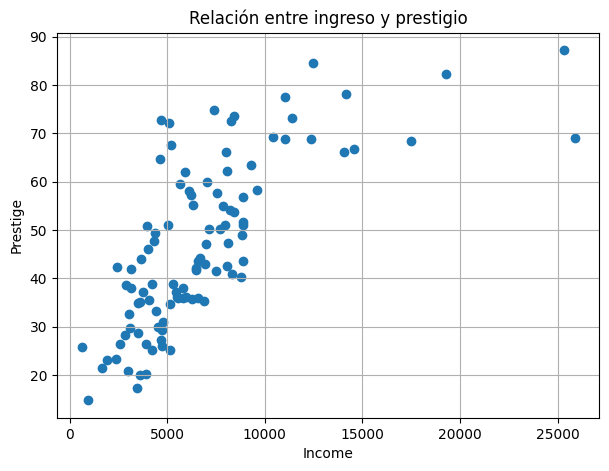

In [17]:
plt.figure(figsize=(7,5))
plt.scatter(df['income'], df['prestige'])
plt.xlabel('Income')
plt.ylabel('Prestige')
plt.title('Relación entre ingreso y prestigio')
plt.grid(True)
plt.show()

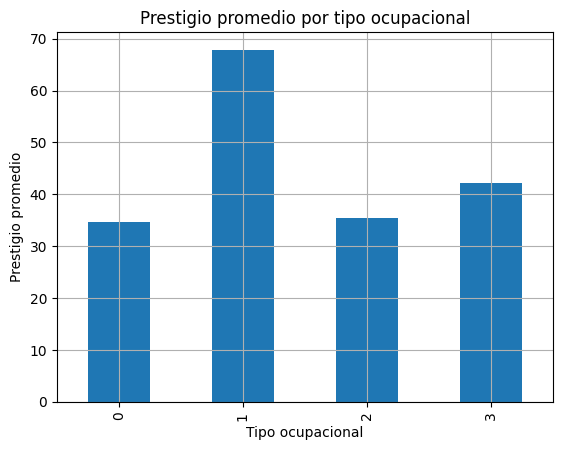

In [22]:
plt.figure(figsize=(7,5))

# Promedio de prestigio por tipo
promedio = df.groupby('type_num')['prestige'].mean()

promedio.plot(kind='bar')

plt.xlabel('Tipo ocupacional')
plt.ylabel('Prestigio promedio')
plt.title('Prestigio promedio por tipo ocupacional')
plt.grid(True)
plt.show()

Análisis de agrupación de ocupaciones

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [25]:
# Variables seleccionadas
columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']

X = df[columnas_cluster].copy()

# Escalamiento
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

# Modelo con 4 clusters
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

# Modelo con 5 clusters
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

# Centroides promedio
print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))

           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00
